In [1]:
from langchain_openai import ChatOpenAI
import os
def get_model():
    """获取聊天模型实例"""
    return ChatOpenAI(
        model="Qwen/Qwen2.5-7B-Instruct",
        base_url="https://api.siliconflow.cn/v1",
        api_key=os.environ.get("SILICONFLOW_API_KEY"),
        temperature=0.2,
    )

# Model
模型是智能体的 **推理引擎** 。它们驱动智能体的决策过程，决定调用哪些工具、如何解释结果以及何时提供最终答案。

除了玩“文字接龙”，许多模型还支持：
- Tool calling - 调用外部工具（如数据库查询或 API 调用）并使用结果在其响应中
- Structrued output - 模型的响应定义好的格式（自定义）
- Multimodality - 多模态能力，输出的格式还有图像、语音、视频等非文本格式
- Reasoning - 推理，模型执行多步推理得出结论


【主要的方法】

- invoke：调用
- stream：流式调用
- batch：批调用

## 模型标准参数

一个聊天模型会接受参数，用于配置其行为。支持的全套参数因模型和提供者而异，但标准参数：

- model  模型 - string - required  字符串（必填）
您想要与提供者一起使用的特定模型的名称或标识符。您也可以使用“：”格式在一个参数中指定模型及其提供者，例如“openai:o1”。
​
- api_key  API 密钥 - string 
用于向模型提供者进行身份验证的密钥。这通常在您注册访问模型时发放。通常通过设置来访问。
​
- temperature  温度 - number
控制模型输出的随机性。数值越高，响应越有创意；数值越低，响应越确定。
​
- max_tokens - number  
限制响应中tokens的总数，有效控制输出可以有多长。
​
- timeout  超时 - number  
在取消请求之前，等待模型响应的最大时间（以秒为单位）。
​
- max_retries  最大重试次数
  - numberdefault:"6"
如果由于网络超时或速率限制等问题导致请求失败，系统将尝试重新发送请求的最大次数。重试使用带有抖动的指数退避策略。网络错误、速率限制（429）和服务器错误（5xx）将自动重试。客户端错误，如 401（未授权）或 404，不会重试。对于在不可靠网络上运行的长代理任务，可以考虑将其增加到 10-15。

## Tool calling

工具可以是function或coroutine，或者是一个schema格式

### 工具
schema格式包括工具的名称、描述和/或参数定义（通常是 JSON 模式），也可以交给函数和协程去执行

### 调用流程
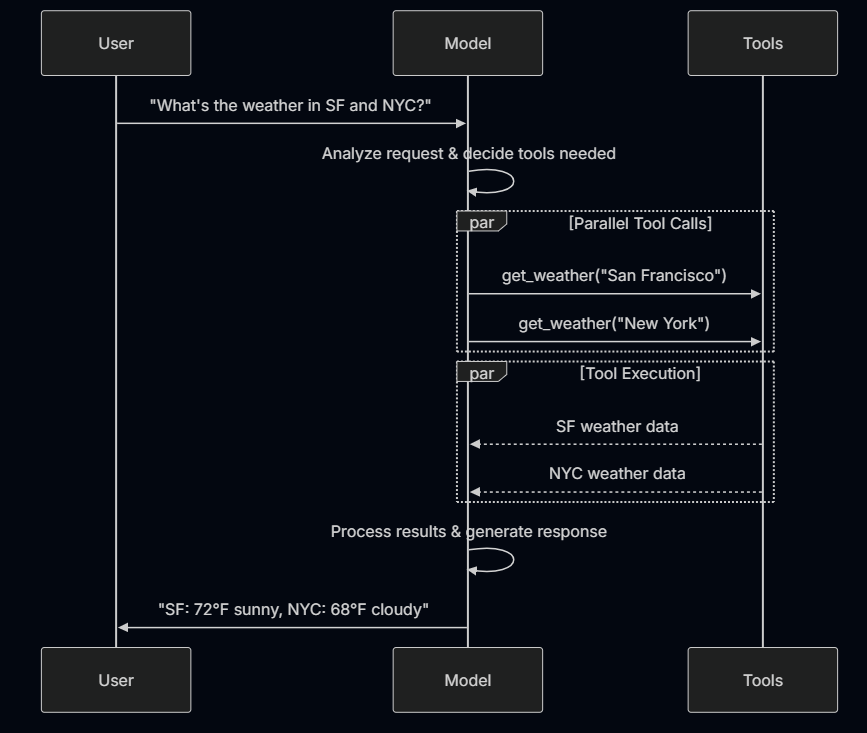

